# Exploración de la definición del target de riesgo

**TFM:** estimación de riesgo de mercado con Machine Learning.

Este notebook es **exploratorio**:
- No modifica `data/processed/initial_market_dataset.csv`.
- No guarda el target definitivo en ningún CSV.
- Sirve para comparar definiciones de evento futuro de riesgo antes de implementarlas.

La propuesta escrita está en `docs/target_definition_proposal.md`.


## 0. Librerías y parámetros del experimento

Fijamos el horizonte (20 días hábiles) y la raíz del proyecto.


In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Parámetros del análisis de target (mismos que en la propuesta)
HORIZON_DAYS = 20          # días hábiles hacia delante
TRADING_DAYS = 252         # factor de anualización
DD_THRESHOLDS = [0.03, 0.05, 0.075, 0.10]  # umbrales de drawdown (en valor absoluto)
VOL_PERCENTILES = [0.80, 0.90]

# Ruta al dataset ya construido en el notebook 01
if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "initial_market_dataset.csv"
print("Dataset:", DATA_PATH.resolve())


Dataset: /Users/victorcorralmorales/Documents/UNIR - IA/TFM/tfm-market-risk-ml/data/processed/initial_market_dataset.csv


## 1. Inspección del dataset actual

Comprobamos estructura, fechas, orden temporal y valores nulos en las features existentes.


In [2]:
# Carga: la columna 'date' pasa a ser el índice temporal
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

print("Filas:", len(df), "| Columnas:", len(df.columns))
print("Primera fecha:", df["date"].min().date())
print("Última fecha:", df["date"].max().date())
print("¿Ordenado por fecha ascendente?:", df["date"].is_monotonic_increasing)
print("\nFrecuencia: una fila por día de mercado (panel diario)\n")

display(df.head(3))
display(df.tail(3))

print("Columnas disponibles:")
print(list(df.columns))

null_pct = (df.isna().mean() * 100).round(2)
print("\nPorcentaje de nulos por columna (%):")
display(null_pct.to_frame(name="pct_nulos"))


Filas: 9159 | Columnas: 29
Primera fecha: 1990-01-02
Última fecha: 2026-05-14
¿Ordenado por fecha ascendente?: True

Frecuencia: una fila por día de mercado (panel diario)



,date,sp500_close,vix,treasury_10y,treasury_2y,treasury_3m,spread_10y_2y,spread_10y_3m,sp500_return_1d,sp500_return_5d,...,sp500_dist_ma200,vix_change_1d,vix_change_5d,vix_ma_20,vix_zscore_252,treasury_10y_change_20d,treasury_2y_change_20d,spread_10y_2y_change_20d,spread_10y_3m_change_20d,curve_inverted_10y_2y
0,1990-01-02,359.690002,17.24,7.94,7.87,7.83,0.07,0.11,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,1990-01-03,358.760010,18.19,7.99,7.94,7.89,0.05,0.10,-0.002586,NaN,...,NaN,0.95,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,1990-01-04,355.670013,19.22,7.98,7.92,7.84,0.06,0.14,-0.008613,NaN,...,NaN,1.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


,date,sp500_close,vix,treasury_10y,treasury_2y,treasury_3m,spread_10y_2y,spread_10y_3m,sp500_return_1d,sp500_return_5d,...,sp500_dist_ma200,vix_change_1d,vix_change_5d,vix_ma_20,vix_zscore_252,treasury_10y_change_20d,treasury_2y_change_20d,spread_10y_2y_change_20d,spread_10y_3m_change_20d,curve_inverted_10y_2y
9156,2026-05-12,7400.959961,17.99,4.46,4.00,3.70,0.46,0.76,-0.001603,0.019525,...,0.094215,-0.39,0.61,18.057,-0.070199,0.20,0.24,-0.04,0.21,0
9157,2026-05-13,7444.250000,17.87,4.46,3.98,3.69,0.48,0.77,0.005849,0.010744,...,0.099758,-0.12,0.48,18.042,-0.106138,0.17,0.22,-0.05,0.19,0
9158,2026-05-14,7501.240234,17.26,4.47,4.00,3.69,0.47,0.78,0.007656,0.022370,...,0.107252,-0.61,0.18,18.008,-0.290817,0.15,0.22,-0.07,0.16,0


Columnas disponibles:
['date', 'sp500_close', 'vix', 'treasury_10y', 'treasury_2y', 'treasury_3m', 'spread_10y_2y', 'spread_10y_3m', 'sp500_return_1d', 'sp500_return_5d', 'sp500_return_20d', 'sp500_vol_20d', 'sp500_vol_20d_ann', 'sp500_vol_60d_ann', 'sp500_rolling_max_252d', 'sp500_drawdown_252d', 'sp500_ma_50', 'sp500_ma_200', 'sp500_dist_ma50', 'sp500_dist_ma200', 'vix_change_1d', 'vix_change_5d', 'vix_ma_20', 'vix_zscore_252', 'treasury_10y_change_20d', 'treasury_2y_change_20d', 'spread_10y_2y_change_20d', 'spread_10y_3m_change_20d', 'curve_inverted_10y_2y']

Porcentaje de nulos por columna (%):


,pct_nulos
date,0.00
sp500_close,0.00
vix,0.00
treasury_10y,0.00
treasury_2y,0.00
treasury_3m,0.00
spread_10y_2y,0.00
spread_10y_3m,0.00
sp500_return_1d,0.01
sp500_return_5d,0.05


## 2. Magnitudes futuras temporales (solo para análisis)

Calculamos dos cantidades que **miran al futuro** respecto al día t:

1. **`future_drawdown_20d`**: peor caída desde el cierre de hoy hasta el mínimo de los **próximos 20 cierres**.
2. **`future_vol_20d_ann`**: volatilidad realizada (std de 20 retornos diarios) × √252.

Las últimas 20 filas quedarán sin valor (no hay 20 días futuros en la muestra).

> Estas columnas **no** se guardan en el CSV procesado.


In [3]:
def compute_future_metrics(close: np.ndarray, horizon: int, trading_days: int):
    """Calcula drawdown y volatilidad futura para cada día t."""
    n = len(close)
    future_dd = np.full(n, np.nan)
    future_vol = np.full(n, np.nan)

    for i in range(n - horizon):
        # Mínimo de los próximos 20 cierres respecto al cierre de hoy
        future_prices = close[i + 1 : i + horizon + 1]
        future_dd[i] = future_prices.min() / close[i] - 1

        # 20 retornos diarios: de t a t+1, ..., de t+19 a t+20
        prices = close[i : i + horizon + 1]
        daily_rets = np.diff(prices) / prices[:-1]
        future_vol[i] = daily_rets.std(ddof=1) * np.sqrt(trading_days)

    return future_dd, future_vol


close = df["sp500_close"].to_numpy()
df["future_drawdown_20d"], df["future_vol_20d_ann"] = compute_future_metrics(
    close, HORIZON_DAYS, TRADING_DAYS
)

# Subconjunto donde el futuro está definido
df_eval = df.dropna(subset=["future_drawdown_20d", "future_vol_20d_ann"]).copy()
print("Días con métricas futuras calculables:", len(df_eval))
print("Días sin target futuro (cola final):", len(df) - len(df_eval))

display(
    df_eval[["date", "sp500_close", "future_drawdown_20d", "future_vol_20d_ann"]].head()
)


Días con métricas futuras calculables: 9139
Días sin target futuro (cola final): 20


,date,sp500_close,future_drawdown_20d,future_vol_20d_ann
0,1990-01-02,359.690002,-0.102060,0.147984
1,1990-01-03,358.760010,-0.099732,0.171083
2,1990-01-04,355.670013,-0.091911,0.170671
3,1990-01-05,352.200012,-0.082964,0.172954
4,1990-01-08,353.790009,-0.087086,0.172068


## 3. Comparativa de definiciones de target (binario)

Exploramos opciones A (solo drawdown), B (solo volatilidad), C (combinado).

**Nota:** los percentiles de volatilidad se calculan aquí sobre **toda la muestra** solo para comparar definiciones. En el entrenamiento final el P80 debe calcularse **solo con train** (ver documento en `docs/`).


In [4]:
# Umbrales de volatilidad (exploración in-sample)
vol_p80 = df_eval["future_vol_20d_ann"].quantile(0.80)
vol_p90 = df_eval["future_vol_20d_ann"].quantile(0.90)
print(f"Umbral exploratorio P80 vol futura: {vol_p80:.4f}")
print(f"Umbral exploratorio P90 vol futura: {vol_p90:.4f}")

rows = []

# A) Solo drawdown
for thr in DD_THRESHOLDS:
    mask = df_eval["future_drawdown_20d"] <= -thr
    n_pos = int(mask.sum())
    pct = n_pos / len(df_eval) * 100
    if pct > 25:
        comment = "Posiblemente laxa (muchos positivos)"
    elif pct < 5:
        comment = "Posiblemente estricta (pocos positivos)"
    else:
        comment = "Razonable"
    rows.append({
        "definicion": f"Drawdown futuro <= -{thr*100:.1f}% (20d)",
        "n_positivos": n_pos,
        "pct_positivos": round(pct, 2),
        "comentario": comment,
    })

# B) Solo volatilidad
for p, label in [(0.80, "P80"), (0.90, "P90")]:
    thr_v = df_eval["future_vol_20d_ann"].quantile(p)
    mask = df_eval["future_vol_20d_ann"] > thr_v
    n_pos = int(mask.sum())
    pct = n_pos / len(df_eval) * 100
    rows.append({
        "definicion": f"Vol futura > {label} (20d)",
        "n_positivos": n_pos,
        "pct_positivos": round(pct, 2),
        "comentario": f"~{(1-p)*100:.0f}% positivos por construcción (muestra completa)",
    })

# C) Combinado (preferencia inicial del TFM)
mask_dd5 = df_eval["future_drawdown_20d"] <= -0.05
mask_vol = df_eval["future_vol_20d_ann"] > vol_p80
mask_comb = mask_dd5 | mask_vol
n_comb = int(mask_comb.sum())
rows.append({
    "definicion": "Combinado: DD<=-5% OR vol>P80",
    "n_positivos": n_comb,
    "pct_positivos": round(n_comb / len(df_eval) * 100, 2),
    "comentario": "Razonable; preferencia inicial del TFM",
})

target_comparison = pd.DataFrame(rows)
display(target_comparison)

# Guardamos en memoria para gráficos (no en CSV)
df_eval["target_combined_exploratory"] = mask_comb.astype(int)


Umbral exploratorio P80 vol futura: 0.1997
Umbral exploratorio P90 vol futura: 0.2517


,definicion,n_positivos,pct_positivos,comentario
0,Drawdown futuro <= -3.0% (20d),2904,31.78,Posiblemente laxa (muchos positivos)
1,Drawdown futuro <= -5.0% (20d),1472,16.11,Razonable
2,Drawdown futuro <= -7.5% (20d),702,7.68,Razonable
3,Drawdown futuro <= -10.0% (20d),341,3.73,Posiblemente estricta (pocos positivos)
4,Vol futura > P80 (20d),1828,20.00,~20% positivos por construcción (muestra compl...
5,Vol futura > P90 (20d),914,10.00,~10% positivos por construcción (muestra compl...
6,Combinado: DD<=-5% OR vol>P80,2306,25.23,Razonable; preferencia inicial del TFM


### 3.1 Multiclase (solo referencia, no recomendada en v1)

Ejemplo didáctico de cómo podría repartirse el riesgo en tres niveles. **No** implementar aún.


In [5]:
# Ejemplo ilustrativo (umbrales arbitrarios para explorar orden de magnitud)
p50_vol = df_eval["future_vol_20d_ann"].quantile(0.50)
p90_vol = df_eval["future_vol_20d_ann"].quantile(0.90)

risk_low = (df_eval["future_drawdown_20d"] > -0.05) & (df_eval["future_vol_20d_ann"] <= p50_vol)
risk_high = (df_eval["future_drawdown_20d"] <= -0.075) | (df_eval["future_vol_20d_ann"] > p90_vol)
risk_mod = ~(risk_low | risk_high)

multiclass_preview = pd.Series({
    "riesgo_bajo (0)": int(risk_low.sum()),
    "riesgo_moderado (1)": int(risk_mod.sum()),
    "riesgo_alto (2)": int(risk_high.sum()),
})
print("Conteo aproximado multiclase (ejemplo):")
display(multiclass_preview.to_frame("dias"))


Conteo aproximado multiclase (ejemplo):


,dias
riesgo_bajo (0),4539
riesgo_moderado (1),3440
riesgo_alto (2),1160


## 4. Visualización: ¿detecta crisis conocidas?

Superponemos el target combinado exploratorio sobre el S&P 500 y revisamos las series futuras.


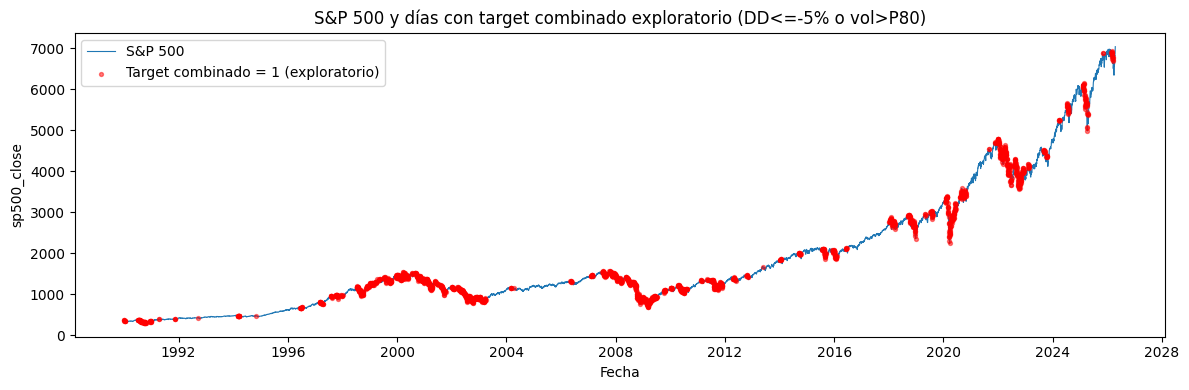

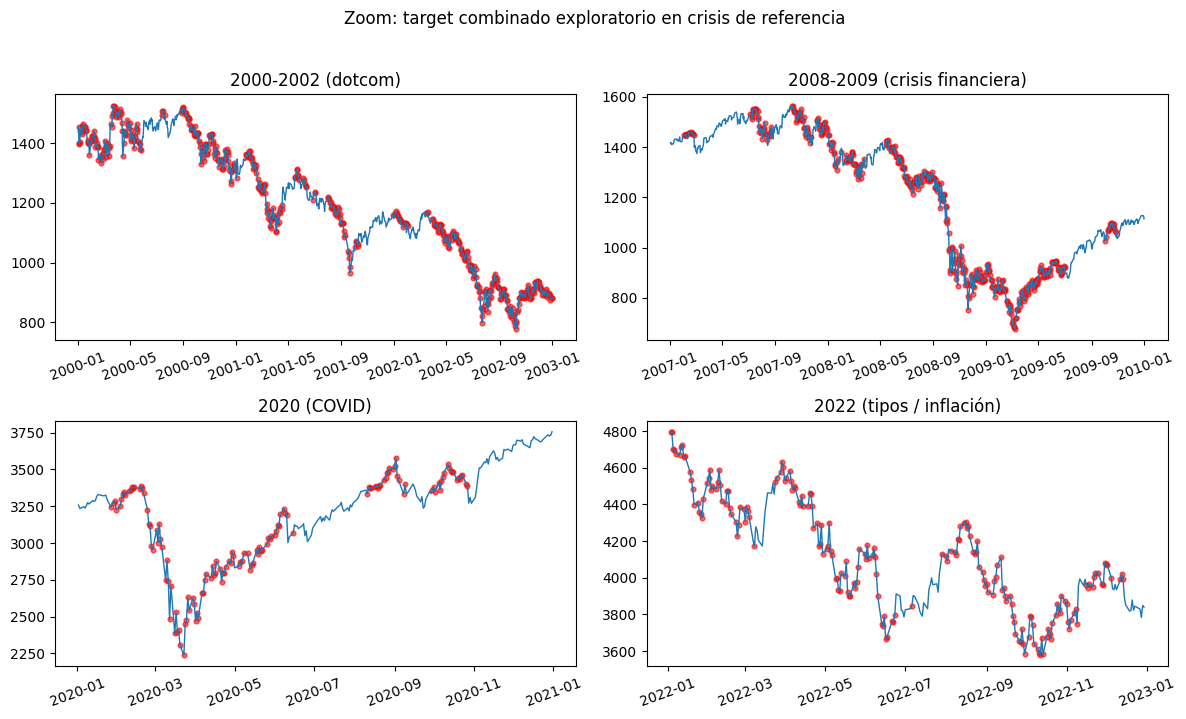

In [6]:
# --- Gráfico 1: S&P 500 con días de target combinado = 1 ---
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_eval["date"], df_eval["sp500_close"], color="tab:blue", linewidth=0.8, label="S&P 500")

# Sombreado donde target combinado exploratorio = 1
risk_days = df_eval[df_eval["target_combined_exploratory"] == 1]
ax.scatter(
    risk_days["date"],
    risk_days["sp500_close"],
    color="red",
    s=8,
    alpha=0.5,
    label="Target combinado = 1 (exploratorio)",
    zorder=3,
)

ax.set_title("S&P 500 y días con target combinado exploratorio (DD<=-5% o vol>P80)")
ax.set_xlabel("Fecha")
ax.set_ylabel("sp500_close")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

# Zoom en periodos de referencia
periods = [
    ("2000-2002 (dotcom)", "2000-01-01", "2002-12-31"),
    ("2008-2009 (crisis financiera)", "2007-01-01", "2009-12-31"),
    ("2020 (COVID)", "2020-01-01", "2020-12-31"),
    ("2022 (tipos / inflación)", "2022-01-01", "2022-12-31"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey=False)
axes = axes.ravel()

for ax, (title, start, end) in zip(axes, periods):
    sub = df_eval[(df_eval["date"] >= start) & (df_eval["date"] <= end)]
    ax.plot(sub["date"], sub["sp500_close"], color="tab:blue", linewidth=1)
    sub_risk = sub[sub["target_combined_exploratory"] == 1]
    ax.scatter(sub_risk["date"], sub_risk["sp500_close"], color="red", s=12, alpha=0.6)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=20)

plt.suptitle("Zoom: target combinado exploratorio en crisis de referencia", y=1.02)
plt.tight_layout()
plt.show()


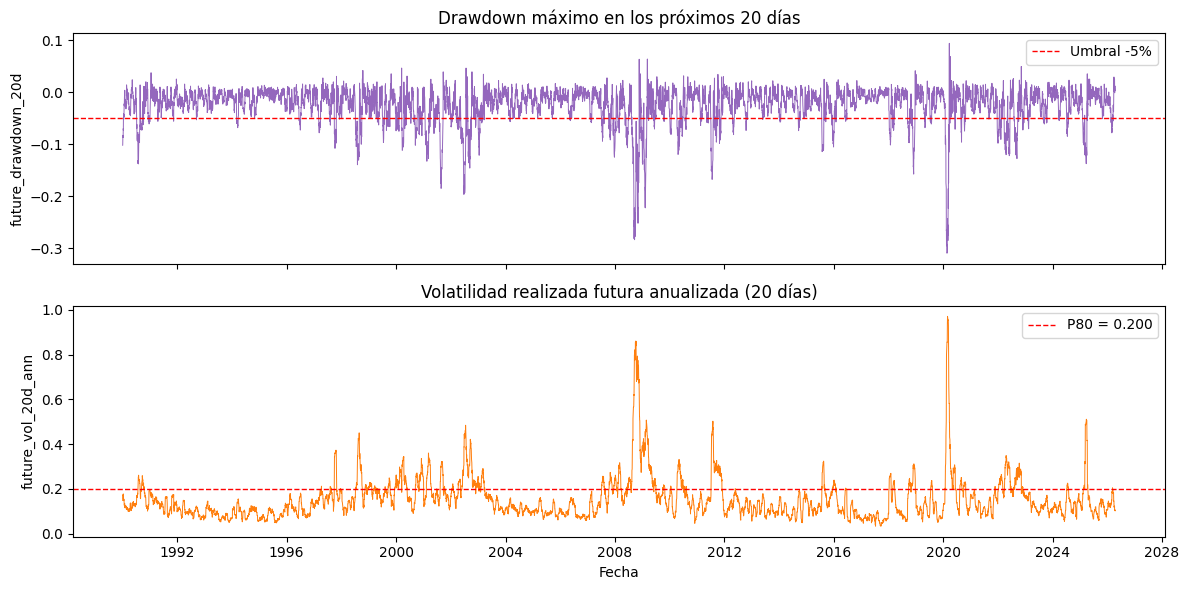

In [7]:
# --- Gráfico 2: evolución de future_drawdown_20d y future_vol_20d_ann ---
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(df_eval["date"], df_eval["future_drawdown_20d"], color="tab:purple", linewidth=0.7)
axes[0].axhline(-0.05, color="red", linestyle="--", linewidth=1, label="Umbral -5%")
axes[0].set_ylabel("future_drawdown_20d")
axes[0].set_title("Drawdown máximo en los próximos 20 días")
axes[0].legend()

axes[1].plot(df_eval["date"], df_eval["future_vol_20d_ann"], color="tab:orange", linewidth=0.7)
axes[1].axhline(vol_p80, color="red", linestyle="--", linewidth=1, label=f"P80 = {vol_p80:.3f}")
axes[1].set_ylabel("future_vol_20d_ann")
axes[1].set_xlabel("Fecha")
axes[1].set_title("Volatilidad realizada futura anualizada (20 días)")
axes[1].legend()

plt.tight_layout()
plt.show()


## 5. Fuga de información (recordatorio)

| Qué | Regla |
|-----|--------|
| **Features** | Solo información hasta el día **t** |
| **Target** | Puede usar **t+1 … t+20** (es lo que queremos predecir) |
| **Percentil de vol** | En producción del dataset final: calcular P80 **solo en train**, no en toda la muestra ni en test |

Detalle ampliado en `docs/target_definition_proposal.md`.


## 6. Resumen de esta exploración

### Opciones analizadas
- **A)** Target solo por drawdown futuro (umbrales 3%, 5%, 7,5%, 10%).
- **B)** Target solo por volatilidad futura > P80 o P90.
- **C)** Target **combinado**: drawdown ≤ −5% **o** volatilidad > P80 (~25% positivos en muestra completa).
- **D)** Multiclase (bajo / moderado / alto): útil más adelante, **no recomendada** en la primera versión.

### Recomendación
Adoptar para la implementación futura el **target binario combinado a 20 días** (`target_risk_20d`), con percentil de volatilidad calculado **solo en entrenamiento**.

### Decisiones abiertas
1. ¿Percentil fijo en train o ventana expanding?
2. ¿Mantener horizonte de 20 días?
3. ¿Métricas orientadas a recall o precisión?
4. ¿Cómo validar temporalmente (split por fechas)?

**Siguiente paso:** la definición adoptada se implementó en `notebooks/02_build_dataset_with_target.ipynb` y se documentó en `docs/target_definition_proposal.md`.
